# Proyecto Integrador
## Consigna

Durante la materia vimos desde como trabajar con un dataset, como curarlo, como dividirlo y vimos muchos modelos tanto de clasificación como de regresión.

El trabajo práctico consiste en seleccionar un dataset de kaggle, visualizar las feature, describirlas, estudiar correlaciones, datos faltantes, etc (básicamente todo lo que vimos durante las primeras 2 clases de la materia). Para ello utilizar las librerias seaborn que genera muchos gráficos de como son los datos.

El dataset corresponderá a un problema de clasificación o de regresión. Elegir al menos 2 modelos, entrenarlos y mostrar los resultados (recordar set de train, val y test).

Analizar el trabajo realizado y comparar resultados con las métricas que corresponda.

El trabajo debe hacerse en forma grupal (grupos de 2 o 3 personas, no más) y es obligatorio.

Deben copiar y pegar el link de google colab en la entrega. Una entrega por grupo.

El trabajo será presentado de forma oral frente a todos sus compañeros. Mi objetivo es que todos aprendan del trabajo propio y del de los demás.

Cualquier duda, lo hablamos en la clase o me mandan un email o mensaje por acá.

Suerte!!

- Comentario: La mayoria de librerias tienen su guia en ingles. Para ello dejo comentarios explicando lo que estoy haciendo para entender que hace o como la usé para futuras referencias mias. Por eso habra varios comentarios en esta entrega que seran entre español e ingles.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("aiexplorer77/digital-burnout-and-productivity-analytics")

print("Path to dataset files:", path)

c:\Users\kmart\OneDrive\Documentos\UPalermo\Cuatrimestre VI\Aprendizaje de Maquina\ProyectoIntegrador\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\kmart\.cache\kagglehub\datasets\aiexplorer77\digital-burnout-and-productivity-analytics\versions\1


In [34]:
#imports
from pandas import *
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split,GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree,DecisionTreeClassifier
from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier



In [ ]:
#Functions
def dataset_info(df):
    """
    Prints basic information about the given DataFrame, including shape, column names, data types, missing values, and summary statistics.
    """
    print("Dataset shape:", df.shape)
    print("\nColumn names:", df.columns.tolist())
    print("\nData types:\n", df.dtypes)
    print("\nMissing values:\n", df.isnull().sum())
    print("\nSummary statistics:\n", df.describe())

def mean_imputation(df):
    """
    Applies mean imputation to the columns with missing values in the given DataFrame.
    """
    try:
        numeric_cols = df.select_dtypes(include=['int64', 'float64']).columns
        #missing_val_columns = df.columns[numeric_cols[df[numeric_cols].isnull().any()]] #Boolean indexing
        missing_val_columns = []
        for col in numeric_cols:
            if df[col].isnull().any():
                missing_val_columns.append(col)
        #Initialize the simpleImputer with mean strategy. Crea la instancia
        imp_mean = SimpleImputer(strategy='mean')
        #imp_mean.fit() recibe un dataframe con las columnas que tienen valores faltantes y calcula la media de cada columna. 
        #retorna el dataframe con las medias calculadas
        if len(missing_val_columns) == 0:
            print("No missing values found in the dataset.")    
        else:
            df[missing_val_columns] = imp_mean.fit_transform(df[missing_val_columns])
        
    except Exception as e:
        print(f"Error occurred while applying mean imputation: {e}")

    return df

def drop_ruido_teorico(df):
    """
    Drops columns that are likely to be theoretical noise.
    """
    dropped_columns = []
    try:
        for col in df.columns.tolist(): 
            #Columnas con solo valores unicos
            if df[col].nunique() == len(df[col]):
                df = df.drop(columns=[col])
                dropped_columns.append(col)
            #Columnas con un solo valor unico
            elif df[col].nunique() == 1:
                df = df.drop(columns=[col])
                dropped_columns.append(col) 
        print(f"""Dropped columns: {dropped_columns}""")
    except Exception as e:
        print(f"Error occurred while dropping theoretical noise columns: {e}")

    return df

def high_correlation(df,target,n=5):        
    """
    Regresa las n columnas con mayor correlacion con target
    """
    try:
        corr_matrix = df.corr()
        target_corr = corr_matrix[target].abs().sort_values(ascending=False)
        top_n_features = target_corr[1:n+1].index.tolist()  # Exclude the target itself
        top_n_features.append(target)  # Include the target column in the final DataFrame
        print(f"Top {n} features most correlated with {target}:\n{target_corr[1:n+1]}")           
        return df[top_n_features]
    except Exception as e:
        print(f"Error occurred while calculating high correlation features: {e}")
        return df

def flag_high_correlation(df, target_col, threshold=0.8):
    """
    Flags numeric columns with correlation above threshold with target.
    """
    numeric_df = df.select_dtypes(include=['int64', 'float64'])
    if target_col in numeric_df.columns:
        corr = numeric_df.corr()[target_col].abs()
        flagged = corr[corr > threshold].drop(target_col).index.tolist()
        print(f"High correlation with '{target_col}' (>{threshold}):\n{flagged}")
    return flagged

def single_feature_leakage_check(X, y, threshold=0.95):
    """
    Trains a trivial decision tree on each feature alone.
    """
    
    
    flagged = []
    for col in X.columns:
        X_single = X[[col]]
        score = cross_val_score(
            DecisionTreeClassifier(max_depth=3), 
            X_single, y, cv=3, scoring='accuracy'
        ).mean()
        if score > threshold:
            print(f"WARNING - '{col}' alone achieves {score:.2%} accuracy")
            flagged.append(col)
    
    if not flagged:
        print("No obvious single-feature leakage detected.")
    return flagged

In [4]:
df = read_csv(path + "\\digital_burnout_productivity_dataset_5M (1).csv")
#Agarrare una muestra de 50,000 filas para el analisis y no ahogara mi computadora
df = df.sample(n=50000, random_state=42)

In [5]:
dataset_info(df)

Dataset shape: (50000, 34)

Column names: ['user_id', 'age', 'occupation', 'work_mode', 'device_usage_type', 'daily_screen_time', 'social_media_hours', 'doomscrolling_duration', 'app_switch_frequency', 'notification_count', 'smartphone_unlocks', 'late_night_device_usage', 'focus_sessions', 'deep_work_hours', 'distraction_frequency', 'task_completion_rate', 'concentration_score', 'sleep_hours', 'sleep_quality', 'caffeine_intake', 'physical_activity', 'stress_level', 'workspace_quality', 'meeting_hours', 'internet_stability', 'remote_work_days', 'motivation_level', 'mental_fatigue', 'emotional_exhaustion', 'work_satisfaction', 'mental_state', 'burnout_risk', 'productivity_score', 'productivity_category']

Data types:
 user_id                      int64
age                          int64
occupation                     str
work_mode                      str
device_usage_type              str
daily_screen_time          float64
social_media_hours         float64
doomscrolling_duration     fl

<Axes: xlabel='productivity_category', ylabel='count'>

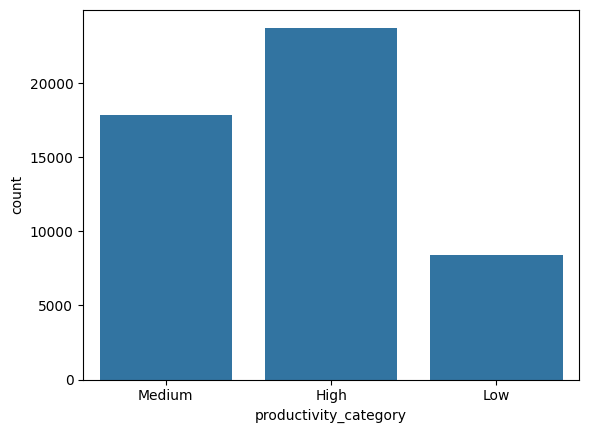

In [53]:
#Countplot as the name sugest cuenta la cantidad de cada categoria en la columna productivity_category
sns.countplot(x='productivity_category', data=df) 

In [7]:
#Preprocesamiento de datos
df = mean_imputation(df)
#Y label
y = df['productivity_category']

#Data leakage
cols_to_drop = ['mental_state', 'burnout_risk', 
                'productivity_score', 'productivity_category']

#Data cleaning
try:
    df_clean= df.drop(columns=cols_to_drop)
    df_clean = drop_ruido_teorico(df_clean) #should drop user_id
except KeyError as e:
    print(f"Error: Failed to clean Dataframe: {e}")



Dropped columns: ['user_id']


In [9]:
#For X_Features
feature_cols = df_clean.select_dtypes(include=['object', 'string']).columns #bool indexing 
df_final = get_dummies(df_clean, columns=feature_cols, drop_first=True, dtype=int)

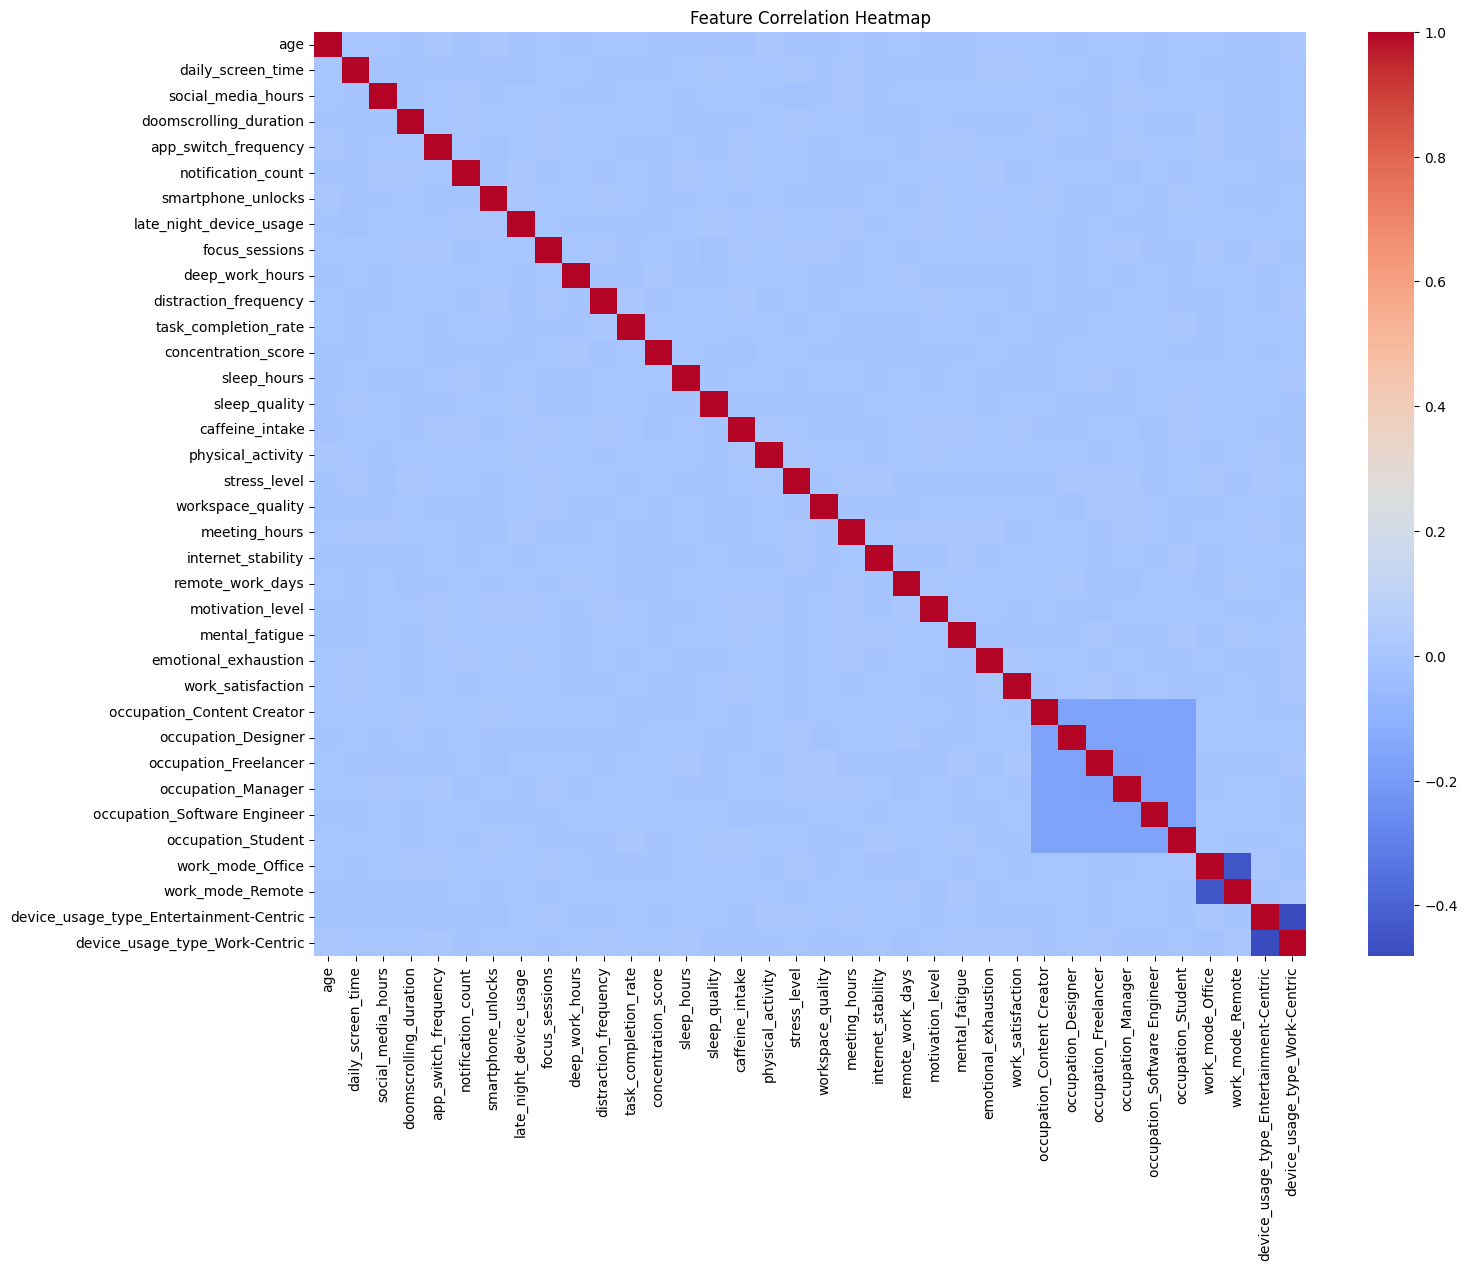

In [16]:
#Armamos correlacion matrix
plt.figure(figsize=(16, 12))
correlation_matrix = df_final.corr()
sns.heatmap(correlation_matrix, annot=False, cmap='coolwarm')
plt.title("Feature Correlation Heatmap")
plt.show()


In [21]:
#Feature selection
X = df_final

#Data splitting
X_train_val, X_test, y_train_val, y_test = train_test_split(X, y, test_size=0.2, random_state=42,stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.25, random_state=42,stratify=y_train_val) 
#Train 0.6, val 0.2, test 0.2

### Stratify
If categories are unbalanced a random shuffle might accidentally have category disbalance

In [22]:
print(f"Train:      {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.0f}%)")
print(f"Validation: {X_val.shape[0]} rows ({X_val.shape[0]/len(X)*100:.0f}%)")
print(f"Test:       {X_test.shape[0]} rows ({X_test.shape[0]/len(X)*100:.0f}%)")

# Confirm stratification held across all three sets
print("\nClass distribution:")
for name, subset in [("Train", y_train), ("Val", y_val), ("Test", y_test)]:
    print(f"{name}: {subset.value_counts(normalize=True).to_dict()}")

Train:      30000 rows (60%)
Validation: 10000 rows (20%)
Test:       10000 rows (20%)

Class distribution:
Train: {'High': 0.47473333333333334, 'Medium': 0.35723333333333335, 'Low': 0.16803333333333334}
Val: {'High': 0.4747, 'Medium': 0.3572, 'Low': 0.1681}
Test: {'High': 0.4748, 'Medium': 0.3572, 'Low': 0.168}


In [ ]:
#RandomForestClassifier
#Instanciamos
try:
    rfc = RandomForestClassifier(
    n_estimators=100, #number of trees in the forest
    random_state=42,
    max_depth=10, #pretty self-explanatory
    class_weight='balanced', #handles class imbalance by adjusting weights inversely proportional to class frequencies
    min_samples_split=5 #minimum number of samples required to split an internal node, helps prevent overfitting
    )
    print("Training RandomForestClassifier...")
    rfc.fit(X_train, y_train)
    print("Done.")
    
except Exception as e:
    print(f"Error occurred while fitting RandomForestClassifier: {e}")  


Training RandomForestClassifier...
Done.


In [24]:

#Evaluation
try:
    train_acc = rfc.score(X_train, y_train)
    val_acc = rfc.score(X_val, y_val)

    print(f"Train accuracy:      {train_acc*100:.2f}%")
    print(f"Validation accuracy: {val_acc*100:.2f}%")
except Exception as e:
    print(f"Error occurred while making predictions with RandomForestClassifier: {e}")


Train accuracy:      86.86%
Validation accuracy: 73.03%


# Hyperparameters Tunnig for RFC
Used GridSearchCV for parallel training some random forest classifier looking for the best hyperparameters to use

In [ ]:

#hiper parameters to tune
param_grid = {
    'max_depth': [4, 6, 8, 10],
    'min_samples_split': [5, 10, 20, 50],
    'max_features': ['sqrt', 'log2']
}
#Base model for grid search
rfc_base = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)
#instanciamos GridSearchCV
grid_search = GridSearchCV(
    estimator=rfc_base,
    param_grid=param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print(f"Best CV score:   {grid_search.best_score_*100:.2f}%")

# Check against validation
best_rfc = grid_search.best_estimator_
val_acc = best_rfc.score(X_val, y_val)
print(f"Validation accuracy with best params: {val_acc*100:.2f}%")

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'max_depth': 10, 'max_features': 'sqrt', 'min_samples_split': 10}
Best CV score:   73.05%
Validation accuracy with best params: 73.12%


# eXtreme Grading Boosting (XGB)

In [33]:
# XGBoost needs numeric labels
le = LabelEncoder() #intantiate label encoder
y_train_enc = le.fit_transform(y_train)
y_val_enc = le.transform(y_val)
y_test_enc = le.transform(y_test)

In [ ]:
print("Class mapping:", dict(zip(le.classes_, le.transform(le.classes_))))
#zip takes two iterables and pairs them element by element:
# le.classes_ is an array of the original class labels (['Low', 'Medium', 'High'])

Class mapping: {'High': np.int64(0), 'Low': np.int64(1), 'Medium': np.int64(2)}


In [38]:
xgb = XGBClassifier(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    eval_metric='mlogloss',      # multiclass log loss
    early_stopping_rounds=20,    # stops if val score doesn't improve for 20 rounds.
    #I personally used the bad apple analogy
    verbosity=1
)

xgb.fit(
    X_train, y_train_enc,
    eval_set=[(X_val, y_val_enc)],  # monitors val loss during training
    verbose=50                       # prints every 50 rounds
)

[0]	validation_0-mlogloss:0.97928
[50]	validation_0-mlogloss:0.58438
[100]	validation_0-mlogloss:0.53136
[150]	validation_0-mlogloss:0.51129
[199]	validation_0-mlogloss:0.50381


,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'multi:softprob'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",20
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes fro

In [37]:
# Evaluating
val_preds = xgb.predict(X_val)
print(f"\nValidation Accuracy: {accuracy_score(y_val_enc, val_preds)*100:.2f}%")
print(classification_report(y_val_enc, val_preds, target_names=le.classes_))


Validation Accuracy: 77.39%
              precision    recall  f1-score   support

        High       0.85      0.86      0.85      4747
         Low       0.80      0.63      0.71      1681
      Medium       0.67      0.73      0.70      3572

    accuracy                           0.77     10000
   macro avg       0.77      0.74      0.75     10000
weighted avg       0.78      0.77      0.77     10000



# Hyperparameter Tunning for XGBoosting

In [40]:

param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.05, 0.1],
    'max_depth': [3, 6],
    'min_child_weight': [1, 10],
    'subsample': [0.8, 1.0]
}

xgb_base = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss',
    verbosity=0
)

grid_search_xgb = GridSearchCV(
    estimator=xgb_base,
    param_grid=param_grid,
    cv=StratifiedKFold(5),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search_xgb.fit(X_train, y_train_enc)

print("Best parameters:", grid_search_xgb.best_params_)
print(f"Best CV score:   {grid_search_xgb.best_score_*100:.2f}%")

best_xgb = grid_search_xgb.best_estimator_
val_preds_tuned = best_xgb.predict(X_val)
print(f"Validation accuracy: {accuracy_score(y_val_enc, val_preds_tuned)*100:.2f}%")
print(classification_report(y_val_enc, val_preds_tuned, target_names=le.classes_))

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Best parameters: {'learning_rate': 0.1, 'max_depth': 6, 'min_child_weight': 10, 'n_estimators': 200, 'subsample': 0.8}
Best CV score:   77.19%
Validation accuracy: 77.77%
              precision    recall  f1-score   support

        High       0.85      0.86      0.86      4747
         Low       0.80      0.65      0.71      1681
      Medium       0.68      0.73      0.70      3572

    accuracy                           0.78     10000
   macro avg       0.78      0.75      0.76     10000
weighted avg       0.78      0.78      0.78     10000



# Testing Models

In [41]:

# Random Forest Classifier
test_preds_rfc = best_rfc.predict(X_test)
test_acc_rfc = accuracy_score(y_test, test_preds_rfc)

# XGBoost  
test_preds_xgb = best_xgb.predict(X_test)
test_acc_xgb = accuracy_score(y_test_enc, test_preds_xgb)

print("=" * 50)
print("FINAL TEST SET RESULTS")
print("=" * 50)

print(f"\nRandom Forest:")
print(f"  Accuracy: {test_acc_rfc*100:.2f}%")
print(classification_report(y_test, test_preds_rfc))

print(f"\nXGBoost:")
print(f"  Accuracy: {test_acc_xgb*100:.2f}%")
print(classification_report(y_test_enc, test_preds_xgb, 
target_names=le.classes_))

FINAL TEST SET RESULTS

Random Forest:
  Accuracy: 74.01%
              precision    recall  f1-score   support

        High       0.82      0.83      0.83      4748
         Low       0.69      0.77      0.73      1680
      Medium       0.65      0.61      0.63      3572

    accuracy                           0.74     10000
   macro avg       0.72      0.74      0.73     10000
weighted avg       0.74      0.74      0.74     10000


XGBoost:
  Accuracy: 77.87%
              precision    recall  f1-score   support

        High       0.85      0.85      0.85      4748
         Low       0.80      0.67      0.73      1680
      Medium       0.68      0.73      0.70      3572

    accuracy                           0.78     10000
   macro avg       0.78      0.75      0.76     10000
weighted avg       0.78      0.78      0.78     10000



# Results and plots

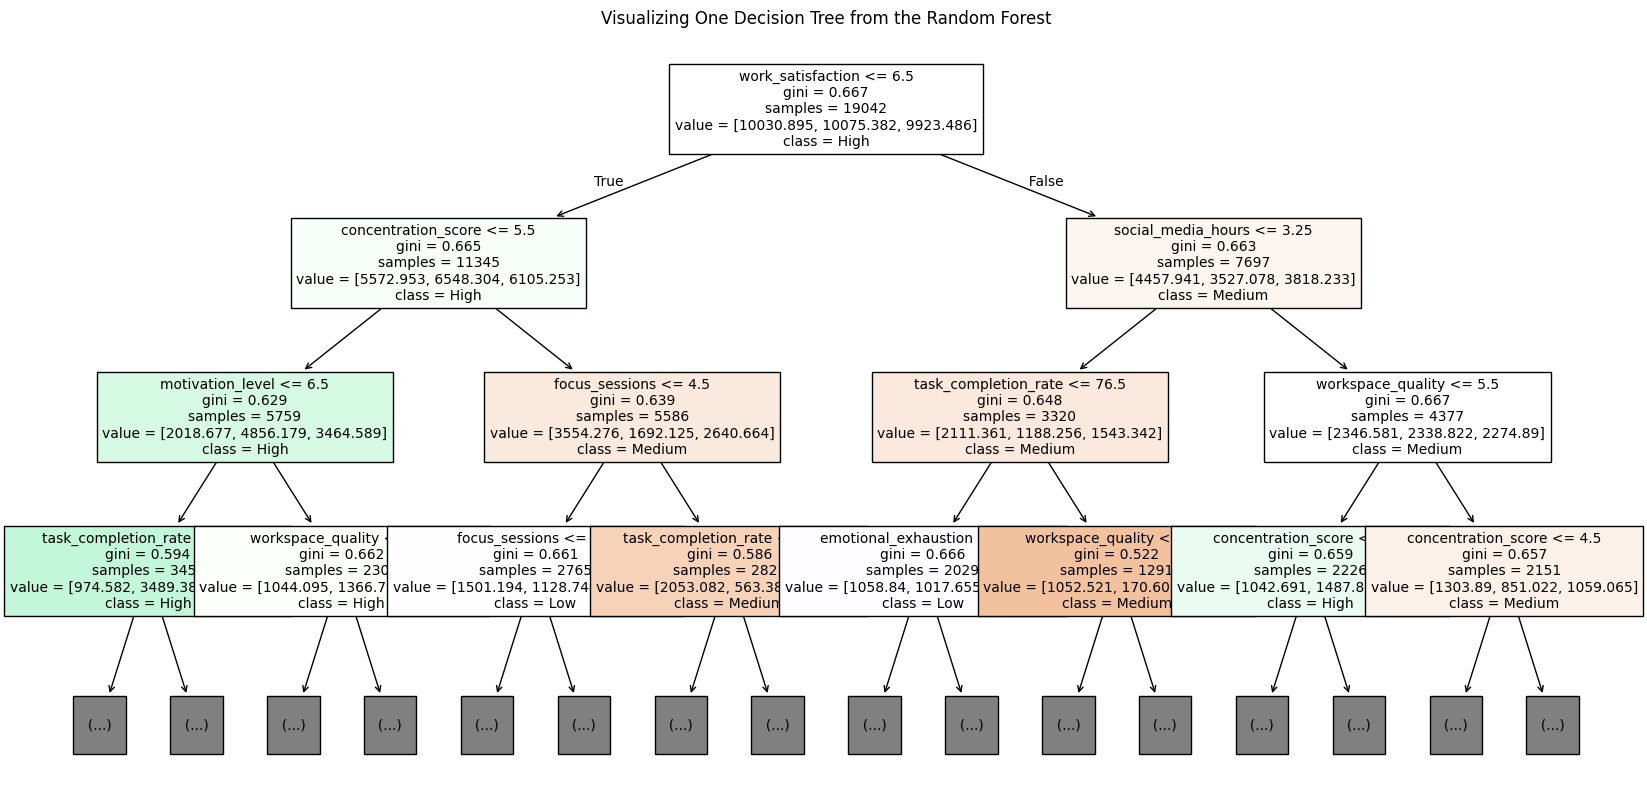

In [ ]:
plt.figure(figsize=(20, 10))

first_tree = rfc.estimators_[0]

plot_tree(
    first_tree,
    feature_names=X.columns,
    class_names=y.unique().astype(str),
    filled=True,
    max_depth=3, # Only show the first 3 levels of decisions for readability
    fontsize=10
)
plt.title("Visualizing One Decision Tree from the Random Forest")
plt.show()

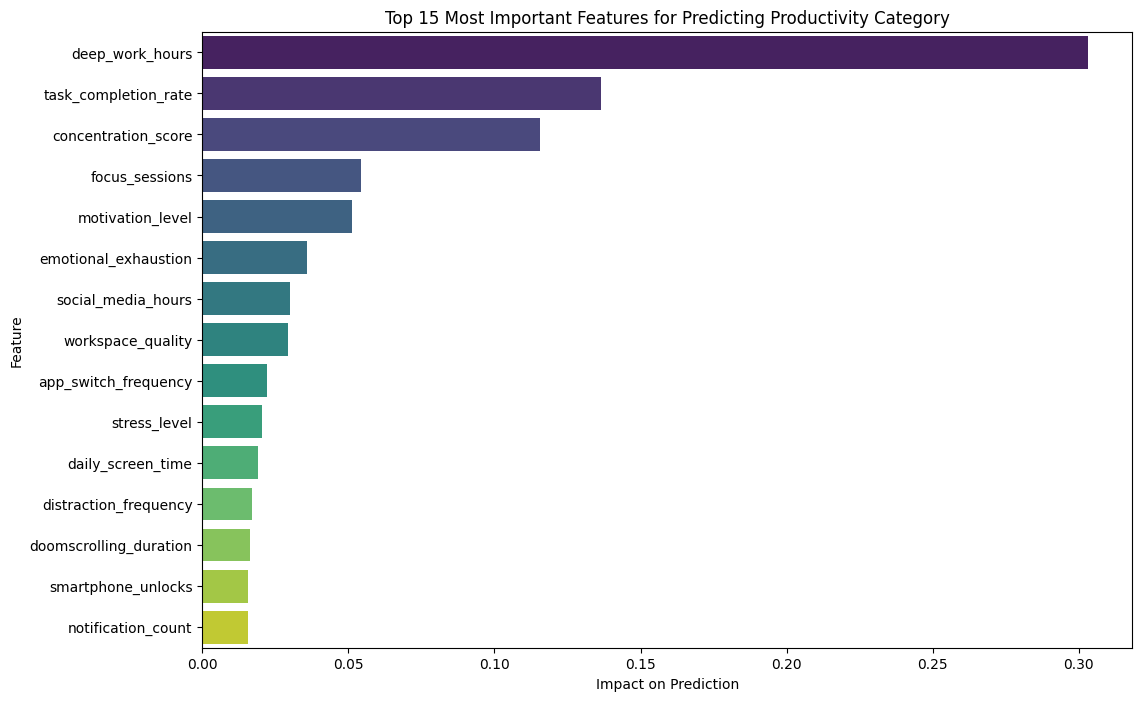

In [29]:
# Extract the importance scores and pair them with your column names
feature_importances = DataFrame({
    'Feature': X.columns,
    'Importance': rfc.feature_importances_
}).sort_values(by='Importance', ascending=False)

# Plot the Top 15 most important features
plt.figure(figsize=(12, 8))
sns.barplot(
    data=feature_importances.head(15), 
    x='Importance', 
    y='Feature', 
    palette='viridis',
    hue= 'Feature',
    legend=False
)
plt.title("Top 15 Most Important Features for Predicting Productivity Category")
plt.xlabel("Impact on Prediction")
plt.ylabel("Feature")
plt.show()

Validation Accuracy: 74.01%

              precision    recall  f1-score   support

        High       0.82      0.83      0.83      4748
         Low       0.69      0.77      0.73      1680
      Medium       0.65      0.61      0.63      3572

    accuracy                           0.74     10000
   macro avg       0.72      0.74      0.73     10000
weighted avg       0.74      0.74      0.74     10000



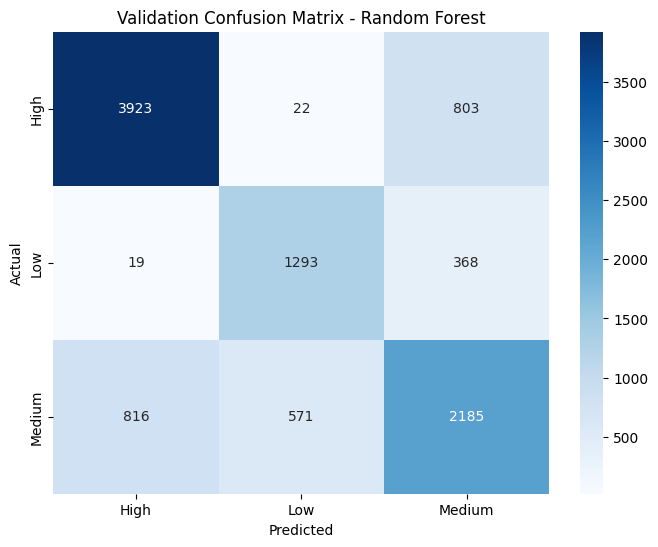

In [47]:
test_predictions_rfc = best_rfc.predict(X_test)

print(f"Validation Accuracy: {accuracy_score(y_test, test_predictions_rfc)*100:.2f}%\n")
print(classification_report(y_test, test_predictions_rfc))

cm = confusion_matrix(y_test, test_predictions_rfc)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=best_rfc.classes_,
            yticklabels=best_rfc.classes_)
plt.title("Validation Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

Validation Accuracy: 77.87%

              precision    recall  f1-score   support

           0       0.85      0.85      0.85      4748
           1       0.80      0.67      0.73      1680
           2       0.68      0.73      0.70      3572

    accuracy                           0.78     10000
   macro avg       0.78      0.75      0.76     10000
weighted avg       0.78      0.78      0.78     10000



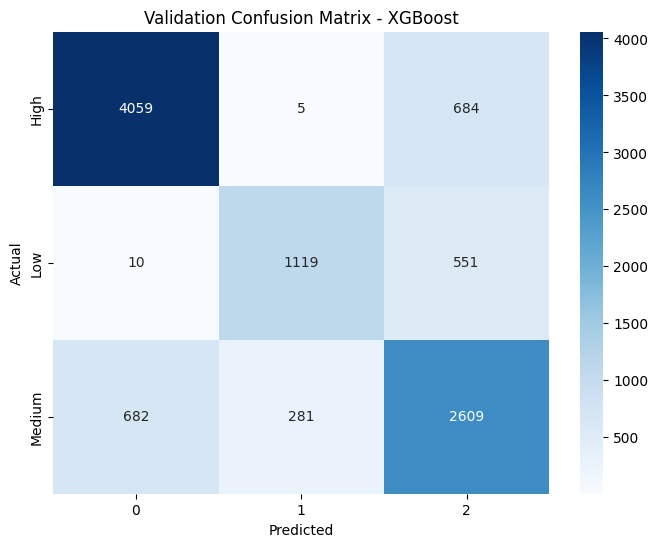

In [51]:
test_predictions_xgb = best_xgb.predict(X_test)

print(f"Validation Accuracy: {accuracy_score(y_test_enc, test_predictions_xgb)*100:.2f}%\n")
print(classification_report(y_test_enc, test_predictions_xgb))

cm = confusion_matrix(y_test_enc, test_predictions_xgb)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='g', cmap='Blues',
            xticklabels=best_xgb.classes_,
            yticklabels=le.classes_)
plt.title("Validation Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [52]:
results = {
    'Model': ['Random Forest', 'XGBoost'],
    'Train Acc': [
        f"{best_rfc.score(X_train, y_train)*100:.2f}%",
        f"{best_xgb.score(X_train, y_train_enc)*100:.2f}%"
    ],
    'Val Acc': ['73.12%', '77.77%'],
    'Test Acc': ['74.01%', '77.87%'],
    'Weighted F1': ['0.74', '0.78']
}


results_df = DataFrame(results)
print(results_df.to_string(index=False))

        Model Train Acc Val Acc Test Acc Weighted F1
Random Forest    86.06%  73.12%   74.01%        0.74
      XGBoost    90.98%  77.77%   77.87%        0.78
